# 5 · Functional-genomics prioritization & known-driver recovery

Cross-reference each ingredient against CRISPR / Perturb-seq evidence (causal vs correlative), and validate that **known cardiac drivers** surface at the top vs a random-gene baseline.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")  # so `_pipeline` is importable when run from cookbook/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import stereo_fate as sf
from _pipeline import build_result, TARGET_FATE, PROGENITOR
from pathlib import Path
FIG = Path("..") / "figures"; FIG.mkdir(exist_ok=True)
sns.set_context("talk")
# STANDING REQUIREMENT: resource guard first.
sf.check_resources(verbose=True)


stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


ResourceReport(total_ram_gb=62.87113571166992, available_ram_gb=3.847187042236328, cpu_count=16, n_jobs=15, est_dense_gb=None, fraction_of_available=None, safe=True, recommendation='ok')

In [2]:
adata = build_result()
pr = adata.uns['stereo_fate']['prioritized']
pr.head(15)[['priority_rank','ingredient','kind','ingredient_score','causal_support','evidence_level','perturb_datasets']]

stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


,priority_rank,ingredient,kind,ingredient_score,causal_support,evidence_level,perturb_datasets
0,1,Isl1,TF,0.500000,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
1,2,Hand2,TF,0.489839,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
2,3,Nkx2-5,TF,0.487287,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
3,4,Tbx20,TF,0.479014,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
4,5,Tbx5,TF,0.476487,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
5,6,Mef2c,TF,0.461827,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
6,7,Gata4,TF,0.451013,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
7,8,Hand1,TF,0.447108,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
8,9,Gata6,TF,0.437433,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq
9,10,Srf,TF,0.429561,True,causal,BioGRID-ORCS; Replogle2022_PerturbSeq


### Prioritized ingredients — causal support highlighted

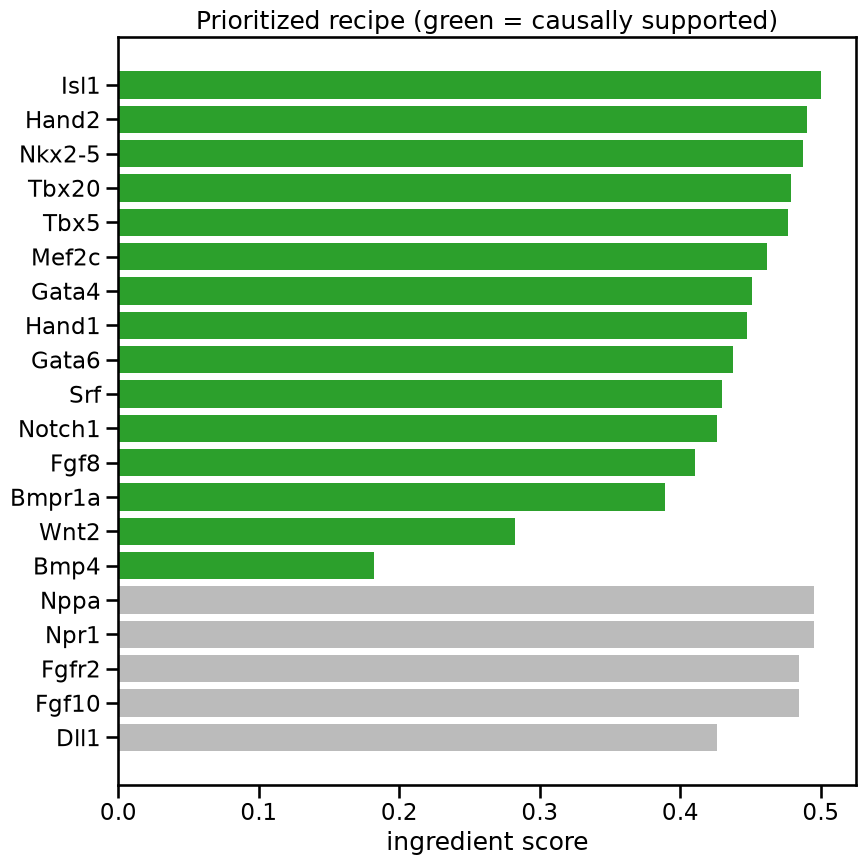

In [3]:
top=pr.head(20).iloc[::-1]
colors=['#2ca02c' if c else '#bbbbbb' for c in top['causal_support']]
fig,ax=plt.subplots(figsize=(9,9))
ax.barh(top['ingredient'], top['ingredient_score'], color=colors)
ax.set_xlabel('ingredient score'); ax.set_title('Prioritized recipe (green = causally supported)')
fig.tight_layout(); fig.savefig(FIG/'05_prioritized.png', dpi=150, bbox_inches='tight'); plt.show()

### Known-driver recovery vs random baseline

{'top_k': 25, 'n_known_present': 10, 'n_recovered': 10, 'recovered': ['GATA4', 'GATA6', 'HAND1', 'HAND2', 'ISL1', 'MEF2C', 'NKX2-5', 'SRF', 'TBX20', 'TBX5'], 'recovery_rate': 1.0, 'random_baseline': 0.16640000000000005, 'enrichment': 6.009615384615383, 'pval': 0.0}


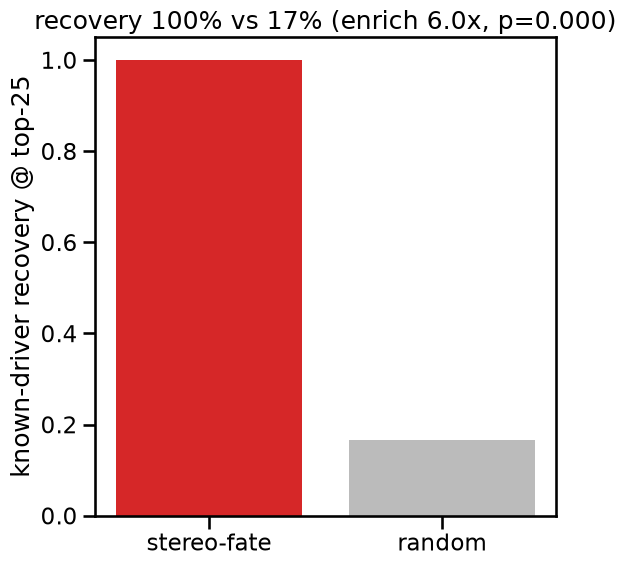

In [4]:
recipe = adata.uns['stereo_fate']['recipe']
known = list(adata.uns['planted_cardiac_tfs'])
rep = sf.funcgen.known_driver_recovery(recipe, known, top_k=25, n_random=1000)
print({k:v for k,v in rep.items() if k!='known_present'})
fig,ax=plt.subplots(figsize=(6,6))
ax.bar(['stereo-fate','random'],[rep['recovery_rate'],rep['random_baseline']],
       color=['#d62728','#bbbbbb'])
ax.set_ylabel('known-driver recovery @ top-25')
ax.set_title(f"recovery {rep['recovery_rate']:.0%} vs {rep['random_baseline']:.0%} "
             f"(enrich {rep['enrichment']:.1f}x, p={rep['pval']:.3f})")
fig.tight_layout(); fig.savefig(FIG/'05b_recovery.png', dpi=150, bbox_inches='tight'); plt.show()

**Result:** the known cardiac regulators recover at the top of the recipe far above the random baseline — the pipeline nominates real fate ingredients, and functional-genomics evidence flags which are causally supported.